In [2]:
import sys
import os
import pandas as pd

sys.path.append(os.path.abspath("../src"))

from preprocessing import (
    add_time_features,
    add_temperature_features,
    create_rain_target,
    create_snow_target
)

df = pd.read_csv("../data/raw/ghcn_daily_data.csv", parse_dates=["DATE"])

df = add_time_features(df)
df = add_temperature_features(df)
df = create_rain_target(df)
df = create_snow_target(df)

In [3]:
# Conteo de valores nulos por columna
print("Valores nulos por columna:")
print(df.isnull().sum())

# Confirmar el rango de fechas en la columna "DATE"
print("Rango de fechas:")
print(df["DATE"].min(), df["DATE"].max())

Valores nulos por columna:
DATE          0
AWND          8
STATION       0
SNOW          0
TMAX          0
TMIN          0
PRCP          0
YEAR          0
MONTH         0
DAY           0
TEMP_MEAN     0
TEMP_RANGE    0
RAIN          0
SNOW_DAY      0
dtype: int64
Rango de fechas:
2020-01-01 00:00:00 2025-12-31 00:00:00


2025-01-01 00:00:00 2025-12-31 00:00:00
DATE
2020    366
2024    366
2021    365
2022    365
2023    365
2025    365
Name: count, dtype: int64


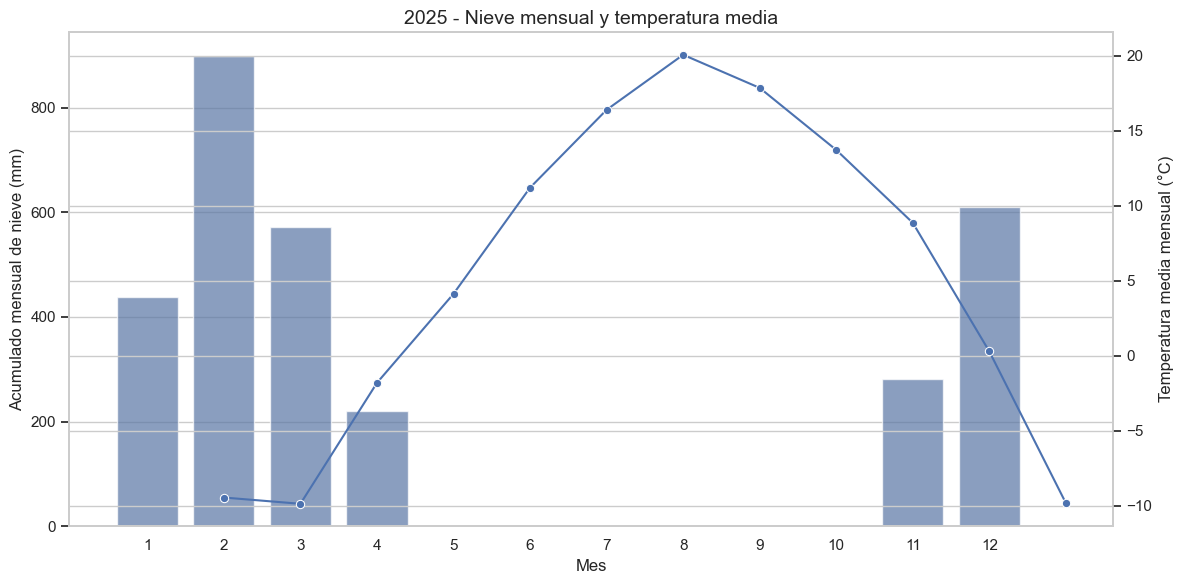

In [4]:
import matplotlib.pyplot as plt
import seaborn as sns


# Analisis exploratorio: Acumulado mensual de nieve en 2025
df_year = df[df["DATE"].dt.year == 2025]
print(df_year["DATE"].min(), df_year["DATE"].max())
print(df["DATE"].dt.year.value_counts())

# Agrupar por mes y calcular el acumulado de nieve y la temperatura media
monthly = (
    df_year
    .groupby("MONTH")
    .agg({
        "SNOW": "sum",
        "TEMP_MEAN": "mean"
    })
)

# Reindexar para asegurar que todos los meses estén presentes
monthly = monthly.reindex(range(1, 13))
monthly = monthly.reset_index()

sns.set_theme(style="whitegrid")

# --- Nieve (barras)
fig, ax1 = plt.subplots(figsize=(12, 6))

sns.barplot(
    data=monthly,
    x="MONTH",
    y="SNOW",
    ax=ax1,
    alpha=0.7
)

ax1.set_ylabel("Acumulado mensual de nieve (mm)", fontsize=12)
ax1.set_xlabel("Mes", fontsize=12)
ax1.set_title(f"{2025} - Nieve mensual y temperatura media", fontsize=14)

# --- Temperatura (línea)
ax2 = ax1.twinx()

sns.lineplot(
    data=monthly,
    x="MONTH",
    y="TEMP_MEAN",
    marker="o",
    ax=ax2
)

ax2.set_ylabel("Temperatura media mensual (°C)", fontsize=12)

plt.tight_layout()
plt.show()


In [5]:
df["DATE"].min(), df["DATE"].max()
df["YEAR"].value_counts().sort_index()

YEAR
2020    366
2021    365
2022    365
2023    365
2024    366
2025    365
Name: count, dtype: int64

In [ ]:
df["RAIN"].value_counts(normalize=True)
# La proporcion de días con lluvia es aproximadamente 43.1%, lo que indica que la lluvia es un evento relativamente común en el conjunto de datos.

RAIN
0    0.568887
1    0.431113
Name: proportion, dtype: float64

In [ ]:
split_year = 2025

train = df[df["YEAR"] < split_year]
test = df[df["YEAR"] >= split_year]
# El corte se ha realizado en el año 2025, lo que permite utilizar datos históricos para entrenar el modelo y evaluar su rendimiento en un conjunto de datos más reciente.